In [20]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.cluster import KMeans

In [13]:
image_path = r"/home/uli/robotics/vision/soccer/output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

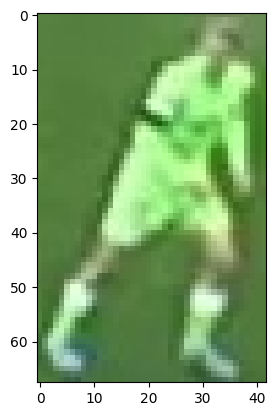

In [17]:
plt.imshow(image)


Take top half image 

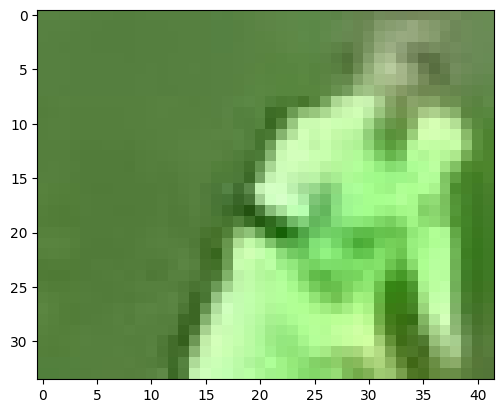

In [19]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)

Cluster the image into two cluster, one for background, one for shirt


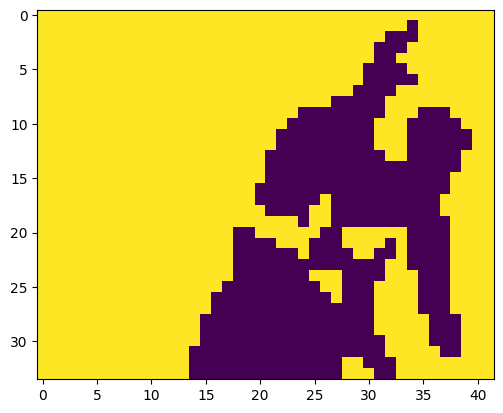

In [24]:
# Reshape the imate into 2d array 
image_2d = top_half_image.reshape(-1, 3)

# perform clustering 
kmeans = KMeans(n_clusters= 2, random_state = 0).fit(image_2d)

# get cluster labels 
labels = kmeans.labels_

# reshape labels into original image shape 
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# display image
plt.imshow(clustered_image)
plt.show()


In [25]:
corner_clusters = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count) 
print(non_player_cluster)

1


In [27]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

0


In [ ]:
kmeans.cluster_centers_[player_cluster] # green color that player is wearing

array([169.27315914, 233.41805226, 143.6888361 ])